1. Cargamos las librerias para el analisis.

In [4]:
#Importamos librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import re 

2. Leemos y asignamos variable al dataframe

In [5]:
df = pd.read_csv("datasets/games.csv")

3. Aplicaremos el formato snake_case (minúsculas + espacios reemplazados por `_`) a los nombres de columnas para obtener nomenclatura consistente y facilitar el trabajo posterior.


In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

#Verificamos que los cambios sean efectivos

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


4. Exploraremos la estructura del DataFrame verificando duplicados, tipos de datos, valores nulos y estadísticas descriptivas.

In [7]:
# 1. Información general
df.info()

# 2. Verificar valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())


# 3. Verificar duplicados
print()
print(f"Filas duplicadas: {df.duplicated().sum()}")
print()

# 4. Primeras filas para ver la estructura
print(df.head())

# 5. Estadísticas descriptivas
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

Valores nulos por columna:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       85

Hallazgos: 


#1. Informacion General:
   
Durante la exploración inicial del dataset, identificamos inconsistencias en los tipos de datos de dos columnas clave:
Problemas detectados:

user_score: Actualmente clasificada como object, pero contiene valores decimales que requieren operaciones numéricas. Esta columna debe convertirse a float64 para permitir cálculos estadísticos.

year_of_release: Está almacenada como float64, cuando conceptualmente representa años de lanzamiento. Inicialmente se consideró convertirla a datetime para facilitar análisis temporales, sin embargo, se decidió convertirla a int64 por las siguientes razones: los datos solo contienen información del año (sin mes ni día específicos), por lo que usar datetime requeriría crear artificialmente valores de mes y día que no existen en la fuente original. Para análisis de videojuegos por año, el tipo int es más apropiado ya que permite operaciones matemáticas directas (filtros por rangos de años, cálculos de diferencias temporales) y agrupaciones por año sin la complejidad innecesaria de fechas completas.
Soluciones implementadas:

Para user_score: Aplicaremos pd.to_numeric() con errors='coerce' para manejar posibles valores no numéricos y convertir a float64.
Para year_of_release: Utilizaremos astype.int para transformar los valores a entero.

#1.1 Valores Nulos: 

Se encontraron valores nulos en diferentes columnas, "name" y "genre" con 2 valores nulos, "year_of_release" con 269, "user_score" con 6701, "rating" con 6766 y "critic_score" con 8578 valores nulos.

Para las columnas de puntuaciones como user_score, rating y criting_score es normal que tengan valoers nulos porque:
No todos los juegos reciben reseñas de críticos
No todos los usuarios califican los juegos
Algunos juegos pueden no tener clasificación ESRB

Estrategias a evaluar:

Investigación de patrones: Analizar si los registros con valores ausentes presentan características comunes (plataformas específicas, géneros, períodos, etc.)
Eliminación selectiva: Considerar eliminar registros si representan un porcentaje pequeño del dataset y no es posible inferir los valores faltantes
Decisión final: TBD - Pendiente de análisis detallado de cada caso

Para las demas columnas "name", "genre" y "year_of_release" consideraremos estas estrategias para resolver los valores nulos:
1. Investigar patrones: ¿Estos juegos sin año tienen características comunes? (plataformas específicas, géneros, etc.)
2. Eliminar registros: Si representan un porcentaje pequeño y no podemos inferir el año

#2. Verificar duplicados:
Se realizó una búsqueda de registros duplicados utilizando el método .duplicated().sum(). Resultado: No se encontraron registros duplicados en el dataset.


5. Correccion de datos

In [8]:
#5.1 Investigacion de patrones en valores ausentes

print(df[df['name'].isnull()])
print()
print()
porcentaje = (2 / len(df)) * 100
print(f"Estos valores nulos representan el {porcentaje:.4}% del dataset")
print()


print(df[df['year_of_release'].isnull()])


      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Estos valores nulos representan el 0.01197% del dataset

                                    name platform  year_of_release  \
183                      Madden NFL 2004      PS2              NaN   
377                     FIFA Soccer 2004      PS2              NaN   
456           LEGO Batman: The Videogame      Wii              NaN   
475           wwe Smackdown vs. Raw 2006      PS2              NaN   
609                       Space Invaders     2600              NaN   
...                                  ...      ...              ...   
16373  PDC World Championship Darts 2008      PSP              

In [9]:
#Declararemos una funcion para extraer el release date de los juegos que lo tengan en el nombre (ej. FIFA Soccer 2004)

def extraer_año(fila):
    if pd.isna(fila['year_of_release']):
        match = re.search(r'(\d{4})', str(fila['name']))
        if match:
            año_encontrado = int(match.group(1))
            if 1970 <= año_encontrado <= 2026:
                return año_encontrado
    return fila['year_of_release']

df['year_of_release'] = df.apply(extraer_año, axis=1)




In [10]:
#5.2 Decisiones sobre eliminacion de registros 

#Se decidio borrar los year_of_release restantes con valores nulos

df.dropna(subset=['year_of_release'], inplace=True)

#Se decidio borrar los "name" con valores nulos (2)

df.dropna(subset=["name"], inplace=True)

#verificamos que los cambios tengan efecto
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8466
user_score         6610
rating             6682
dtype: int64


In [11]:
#5.3 Conversion de datos

#Decidimos convertir "user_score" a float y los "TBD" a "NaN"

df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

#Decidimos hacer "year_of_release" de float a int
df['year_of_release'] = df['year_of_release'].astype(int)

#Verificamos los cambios
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16461 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16461 non-null  object 
 1   platform         16461 non-null  object 
 2   year_of_release  16461 non-null  int64  
 3   genre            16461 non-null  object 
 4   na_sales         16461 non-null  float64
 5   eu_sales         16461 non-null  float64
 6   jp_sales         16461 non-null  float64
 7   other_sales      16461 non-null  float64
 8   critic_score     7995 non-null   float64
 9   user_score       7473 non-null   float64
 10  rating           9779 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


Justificación de Decisiones para el Tratamiento de Valores Ausentes
1. Tratamiento de la columna "name"
Decisión: Eliminación de registros con valores nulos.

Justificación: Se procedió a eliminar los 2 registros que contenían valores ausentes en la columna "name" (0.01197% del dataset total) debido a las siguientes consideraciones:

Imposibilidad de recuperación: No existe una metodología lógica para inferir el nombre de un videojuego a partir de las demás variables disponibles
Impacto mínimo: El porcentaje de registros afectados es insignificante estadísticamente.

Integridad de datos: Mantener registros sin identificación del producto comprometería la calidad del análisis

2. Tratamiento de la columna "year_of_release"
Decisión: Implementación de función de extracción de años seguida de eliminación selectiva.

Justificación: Se desarrolló una estrategia de dos fases para maximizar la recuperación de datos:

Fase 1 - Extracción automatizada:
- Se implementó la función extraer_año() que identifica patrones de años (formato YYYY) en los nombres de juegos
- Esta función opera exclusivamente sobre registros con valores nulos, preservando la integridad de los datos existentes
- Se estableció un rango de validación (1970-2026) para garantizar la coherencia temporal de los datos extraídos
- Resultado: Recuperación exitosa de múltiples registros que contenían información temporal implícita

Fase 2 - Eliminación de valores residuales:
- Los valores nulos restantes después de la extracción representan un porcentaje reducido del dataset
- Se decidió eliminar estos registros considerando que:
  - La ausencia del año de lanzamiento compromete significativamente los análisis temporales
  - Mantener registros incompletos podría introducir sesgos en estudios de tendencias por períodos
  - El impacto en el tamaño muestral es mínimo tras la recuperación previa

3. Conversion de datos

Conversión de user_score (object → float)
Justificación:


La columna user_score se encontraba almacenada como tipo object debido a la presencia de valores no numéricos ('TBD' - To Be Determined) mezclados con puntuaciones numéricas decimales. Esta inconsistencia en el formato impedía el análisis cuantitativo de las puntuaciones de usuarios.

Proceso implementado:

-Conversión automática de valores 'TBD' a NaN durante la transformación a float
-Preservación de la precisión decimal necesaria para el análisis estadístico
-Eliminación de la ambigüedad de tipos que dificultaba las operaciones matemáticas
Beneficios obtenidos:


-Habilitación de cálculos estadísticos (media, mediana, correlaciones)
-Compatibilidad con funciones de análisis numérico
-Tratamiento consistente de valores faltantes

Conversión de year_of_release (float → int)
Justificación técnica:

La columna year_of_release estaba incorrectamente tipificada como float, generando valores decimales innecesarios para una variable que representa años calendario (valores enteros por naturaleza).

Proceso implementado:

-Conversión a tipo int para eliminar decimales espurios
-Optimización del uso de memoria
-Mejora en la legibilidad y interpretación de los datos temporales
Beneficios obtenidos:

-Representación semánticamente correcta de los años
-Facilitación de operaciones de agrupamiento temporal
-Reducción del espacio de almacenamiento requerido

4. Resultado del proceso de limpieza
La implementación de esta metodología permitió:

Maximizar la retención de datos: Recuperación de información válida antes de proceder con eliminaciones

Garantizar la calidad: Eliminación selectiva de registros irrecuperables

Preparar el dataset: Obtención de un conjunto de datos limpio y consistente para análisis posteriores

Esta aproximación equilibra la preservación de información valiosa con la necesidad de mantener la integridad y calidad del dataset para los análisis subsecuentes.

6. Calcularemos las ventas total para cada juego y colocaremos estos valores en una columna separada.

In [12]:
df["total_sales"] = df["na_sales"] + df["eu_sales"] + df["jp_sales"] + df["other_sales"]

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


Paso 3. Analizar los datos

3.1 Mira cuántos juegos fueron lanzados en diferentes años ¿Son significativos los datos de cada período?

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     830
2003     779
2004     764
2005     941
2006    1008
2007    1198
2008    1429
2009    1427
2010    1255
2011    1137
2012     653
2013     545
2014     581
2015     606
2016     502
Name: count, dtype: int64


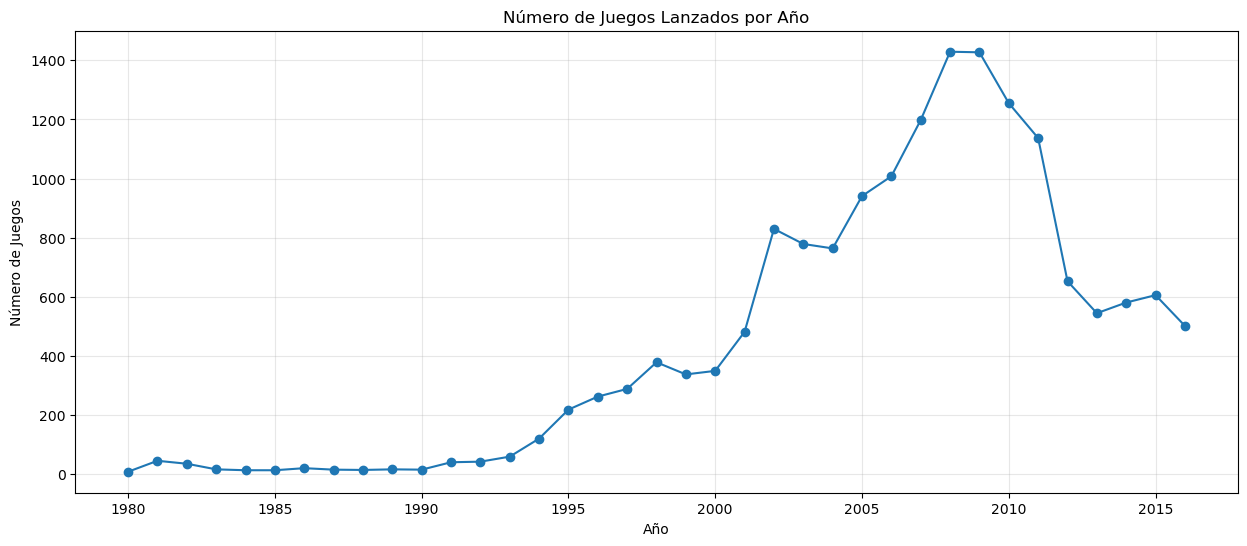

In [13]:
juegos_por_año = df["year_of_release"].value_counts().sort_index()

print(juegos_por_año)

plt.figure(figsize=(15, 6))
plt.plot(juegos_por_año.index, juegos_por_año.values, marker='o')
plt.title('Número de Juegos Lanzados por Año')
plt.xlabel('Año')
plt.ylabel('Número de Juegos')
plt.grid(True, alpha=0.3)
plt.show()

Con base en los resultados obtenidos, podemos identificar tres períodos claramente diferenciados en el dataset:

1. Período Inicial (1980-1994): Datos Limitados

Representa los primeros años de la industria de videojuegos
Volumen de lanzamientos: 9-121 juegos por año
Limitación: Muestra pequeña que puede no ser representativa de tendencias generales
2. Período de Crecimiento (1995-2011): Datos Altamente Significativos

Coincide con la expansión masiva de la industria
Volumen de lanzamientos: 219-1,429 juegos por año
Fortaleza: Muestras robustas que permiten análisis estadísticos confiables
Incluye el pico máximo en 2008-2009 (>1,400 juegos anuales)
3. Período Reciente (2012-2016): Datos Moderadamente Significativos

Refleja cambios en el mercado y posibles limitaciones del dataset
Volumen de lanzamientos: 502-653 juegos por año
Consideración: La disminución puede reflejar cambios en la metodología de recopilación de datos

3.2 Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [14]:
#Ordenamos las ventas por plataforma
ventas_por_plataforma = df.groupby('platform')['total_sales'].sum()
ventas_por_plataforma.sort_values(ascending=False, inplace=True)
print(ventas_por_plataforma)

#Vemos el top 10 en ventas por plataforma
top_plataformas = ventas_por_plataforma.head(10).index.tolist()
print("Top 10 plataformas:", top_plataformas)


platform
PS2     1247.28
X360     961.30
PS3      931.34
Wii      891.18
DS       802.79
PS       727.58
PS4      314.14
GBA      312.88
PSP      290.34
3DS      257.81
PC       256.11
GB       254.43
XB       252.66
NES      251.05
N64      218.01
SNES     200.04
GC       197.03
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64
Top 10 plataformas: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS']


In [15]:
#Creamos tabla basada en los datos de cada año.
ventas_plataforma_año = df[df['platform'].isin(top_plataformas)].groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack(fill_value=0)
print(ventas_plataforma_año.head(10))


year_of_release  1985  1994   1995  1996    1997    1998    1999   2000  \
platform                                                                  
3DS              0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.00   
DS               0.02  0.00   0.00   0.0    0.00    0.00    0.00   0.00   
GBA              0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.07   
PS               0.00  6.03  35.96  94.7  136.17  169.49  144.53  96.37   
PS2              0.00  0.00   0.00   0.0    0.00    0.00    0.00  39.17   
PS3              0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.00   
PS4              0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.00   
PSP              0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.00   
Wii              0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.00   
X360             0.00  0.00   0.00   0.0    0.00    0.00    0.00   0.00   

year_of_release    2001    2002  ...    2007    2008    2009    2010    2011  \
platform           

In [16]:
# 1. Calculamos la vida útil por plataforma
platform_life = df.groupby('platform')['year_of_release'].agg(['min', 'max'])
platform_life['duration'] = platform_life['max'] - platform_life['min']

# 2. Filtramos plataformas con 0 años (ruido) y sacamos el promedio
# Usamos plataformas con duración > 0 para que el promedio sea real
average_duration = platform_life.query('duration > 0')['duration'].mean()

print(f"Las plataformas duran en promedio: {average_duration:.1f} años")

Las plataformas duran en promedio: 8.4 años


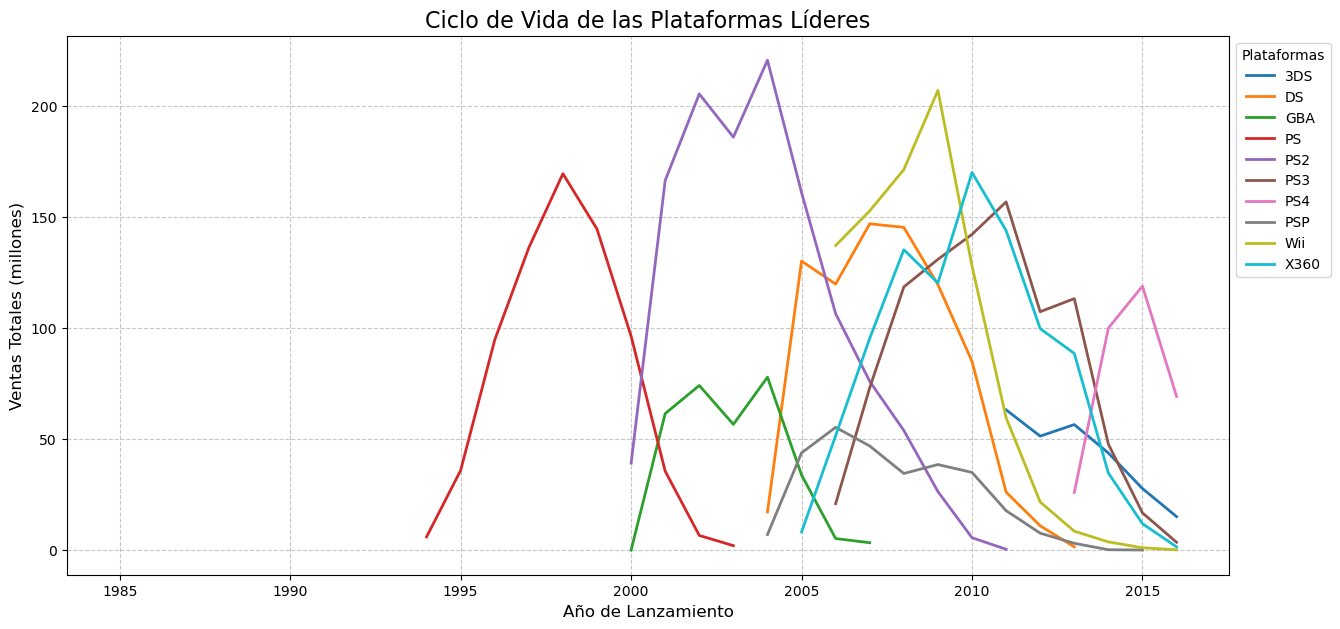

In [17]:
#verificamos ventas por año de las top 10

import matplotlib.pyplot as plt


df_top = df[df['platform'].isin(top_plataformas)]

pivot_top = df_top.pivot_table(index='year_of_release', 
                               columns='platform', 
                               values='total_sales', 
                               aggfunc='sum')

pivot_top.plot(figsize=(15, 7), linewidth=2)


plt.title('Ciclo de Vida de las Plataformas Líderes', fontsize=16)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Totales (millones)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Plataformas', bbox_to_anchor=(1.0, 1), loc='upper left')

plt.show()

Conclusiones: 

Vida útil promedio: Las plataformas más exitosas tienen un ciclo de vida promedio de aproximadamente 8.4 años. Durante este periodo, la consola nace, alcanza un pico de popularidad y finalmente desaparece del mercado ante la llegada de nuevas tecnologías.

Ritmo de aparición y desaparición: Generalmente, las nuevas plataformas aparecen con fuerza cada 5 o 6 años. Esto se observa en el gráfico al notar que, cuando una plataforma líder (como la PS2) alcanza su punto máximo de ventas, la siguiente generación (PS3) suele estar entrando al mercado.

Desaparición: Una vez que la nueva generación se establece, la plataforma antigua tarda entre 3 y 4 años en ver sus ventas reducidas a niveles mínimos.

Observaciones sobre el relevo generacional: Existe un periodo de traslape (overlap) donde ambas generaciones conviven. Por ejemplo, se observa claramente cómo el declive de la Wii coincide directamente con el ascenso de plataformas más modernas hacia 2010-2011.

3.3 Definir el periodo relevante

In [18]:
# Filtramos para quedarnos solo con datos recientes 
df_recent = df[df['year_of_release'] >= 2013].copy()

Justificacion:

Para predecir 2017, necesitamos años que reflejen la tecnología actual (PS4, Xbox One, Wii U).
Decisión: Aunque el promedio de vida es de ~8 años, el mercado cambia rápido. Lo ideal es tomar los datos de los últimos 3 a 5 años (de 2012 o 2013 en adelante).
Por qué: Porque en 2013 se lanzaron las consolas de generación actual en ese dataset.

3.4 Identificar Líderes y Potencialmente Rentables

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.78
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


<Axes: xlabel='year_of_release'>

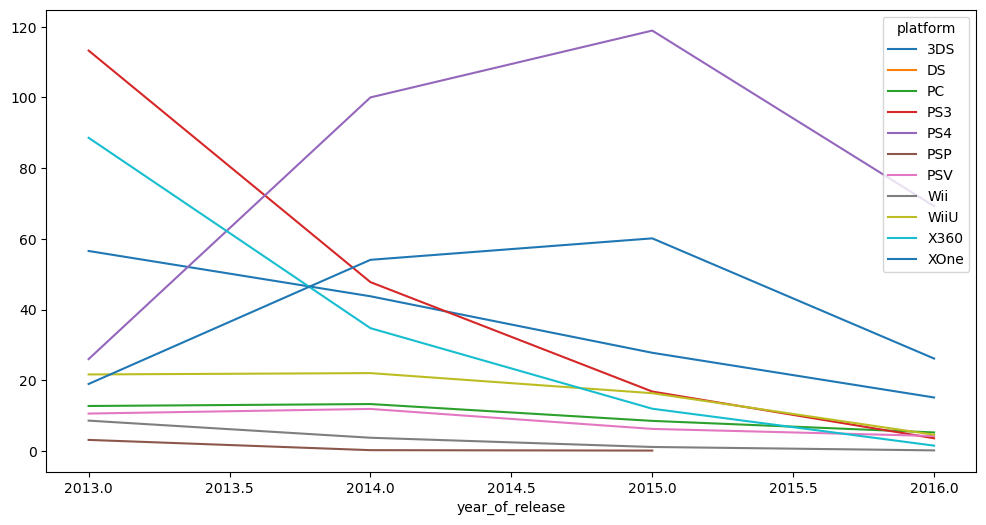

In [19]:
# Ventas totales por plataforma en el periodo reciente
platform_sales = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales)

# Análisis visual para ver quién crece y quién baja
pivot_recent = df_recent.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')
pivot_recent.plot(figsize=(12,6))

Conclusiones: 

1. Plataformas en Crecimiento y Consolidación (Líderes)
PS4 (PlayStation 4): Es la líder indiscutible del mercado. Aunque el gráfico muestra una caída en 2016 (atribuible a datos incompletos del dataset), es la plataforma que alcanzó el pico más alto de ventas superando los 100 millones anuales. Su trayectoria indica que será la plataforma más rentable en 2017.

Xbox One (XOne): Muestra un comportamiento similar a PS4, estableciéndose como la segunda plataforma de sobremesa más importante. Es un fuerte contendiente para las campañas de marketing de 2017.

2. Plataformas en Declive Definitivo (Generación Anterior)
PS3 y Xbox 360 (X360): Estas plataformas muestran una caída estrepitosa desde 2013. Han cumplido su ciclo de vida y para 2017 sus ventas serán marginales. Invertir recursos en estos sistemas representaría un riesgo alto con bajo retorno.

3DS y WiiU: A pesar de haber tenido relevancia, muestran una tendencia negativa constante. La 3DS resiste mejor que las demás portátiles, pero su mercado se está contrayendo frente al dominio de las consolas de sobremesa actuales.

3. Plataformas de Nicho Estable
PC: Aunque sus ventas anuales son menores en comparación con el pico de PS4, su línea es notablemente estable. A diferencia de las consolas, el PC no desaparece del mercado con el tiempo, lo que la convierte en una plataforma de bajo riesgo y ventas constantes a largo plazo.

3.5 Diagrama de caja de ventas globales

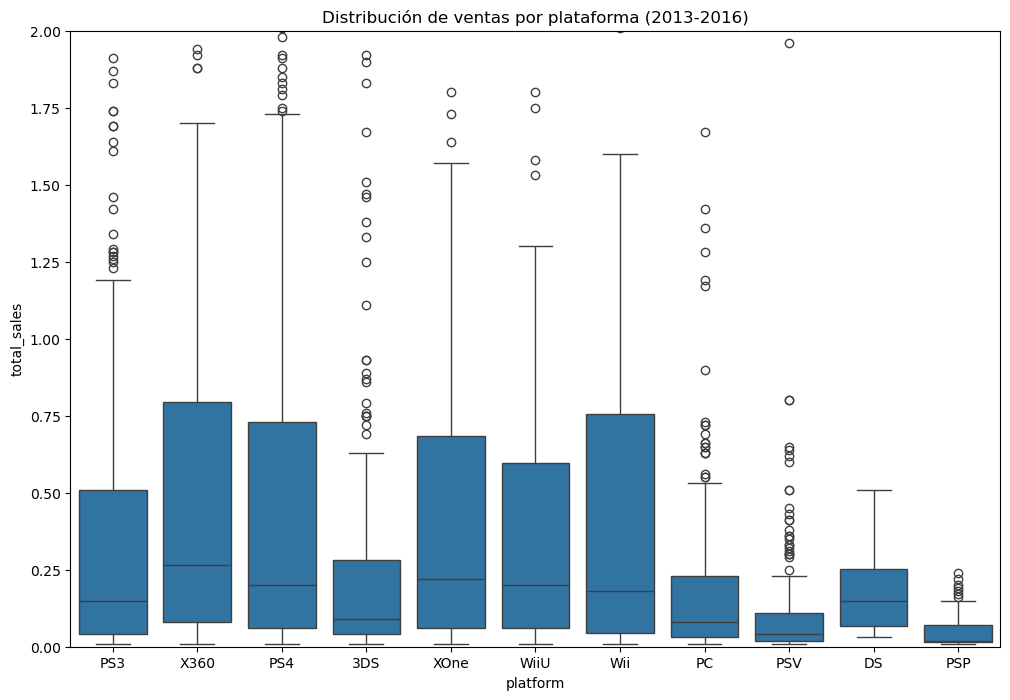

In [20]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_recent, x='platform', y='total_sales')
plt.ylim(0, 2) # Zoom para ver mejor la caja (sin los outliers extremos)
plt.title('Distribución de ventas por plataforma (2013-2016)')
plt.show()

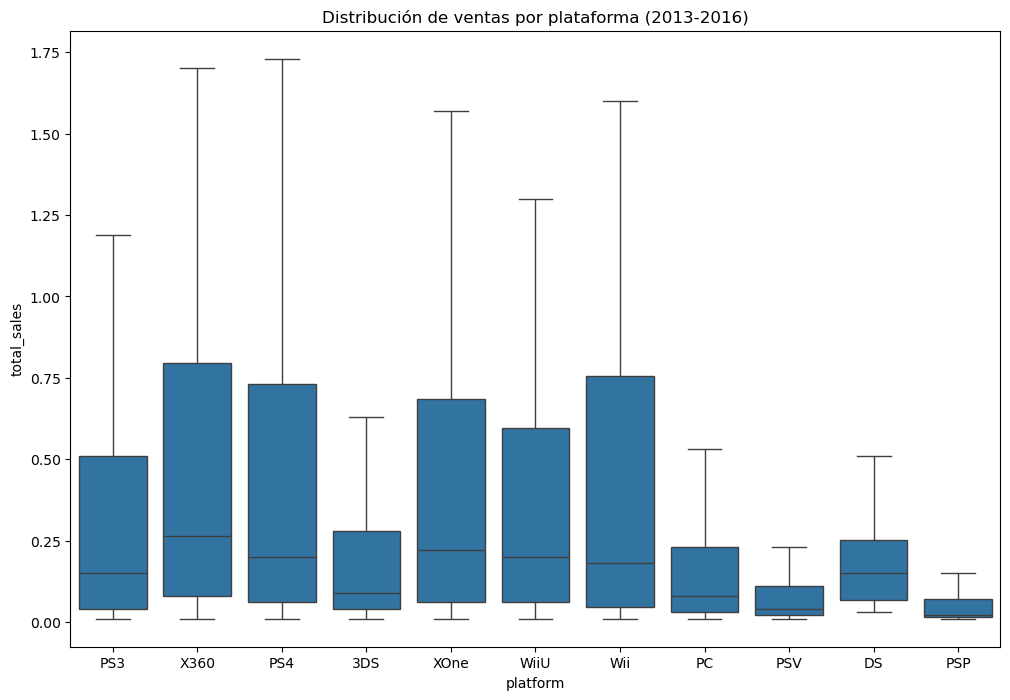

In [21]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_recent, x='platform', y='total_sales', showfliers = False)
#plt.ylim(0, 2) <- Ya no es necesario
plt.title('Distribución de ventas por plataforma (2013-2016)')
plt.show()

3.6 Análisis de Reseñas (Crítica vs. Ventas)

critic_score    0.406568
user_score     -0.031957
total_sales     1.000000
Name: total_sales, dtype: float64


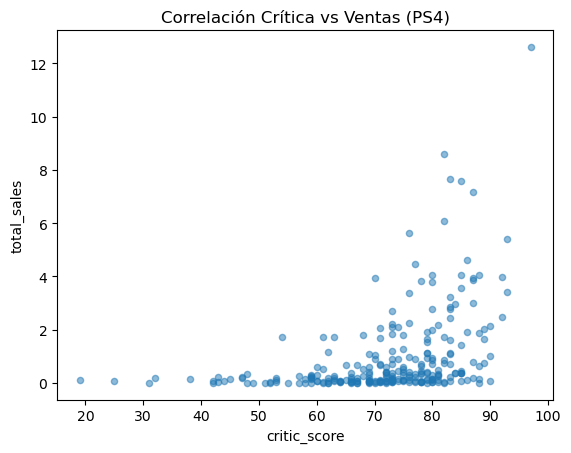

In [22]:
# Gráfico de dispersión para PS4

ps4_data = df_recent[df_recent['platform'] == 'PS4']
ps4_data.plot(kind='scatter', x='critic_score', y='total_sales', alpha=0.5)
plt.title('Correlación Crítica vs Ventas (PS4)')

# Calcular correlación
print(ps4_data[['critic_score', 'user_score', 'total_sales']].corr()['total_sales'])

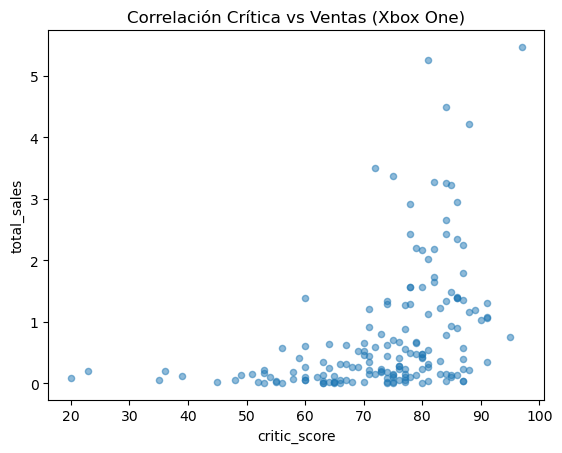

Correlación para Xbox One:
critic_score    0.416998
user_score     -0.068925
total_sales     1.000000
Name: total_sales, dtype: float64


In [23]:
# Filtramos datos de Xbox One y quitamos los valores vacíos
xone_data = df_recent[df_recent['platform'] == 'XOne']

# Hacemos el gráfico
xone_data.plot(kind='scatter', x='critic_score', y='total_sales', alpha=0.5)
plt.title('Correlación Crítica vs Ventas (Xbox One)')
plt.show()

# Calculamos la correlación
print("Correlación para Xbox One:")
print(xone_data[['critic_score', 'user_score', 'total_sales']].corr()['total_sales'])

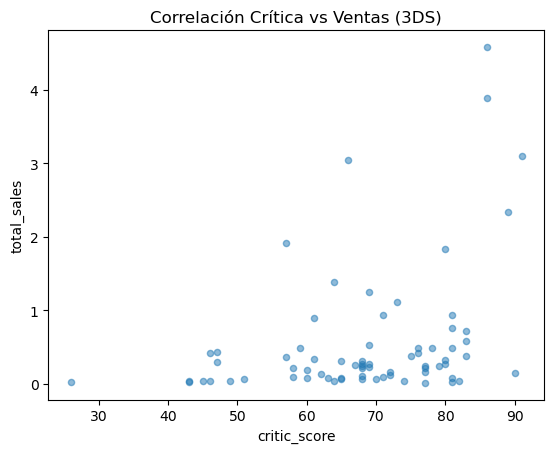

Correlación para 3DS:
critic_score    0.357057
user_score      0.241504
total_sales     1.000000
Name: total_sales, dtype: float64


In [24]:
# Filtramos datos de 3DS y quitamos los valores vacíos
ds3_data = df_recent[df_recent['platform'] == '3DS']

# Hacemos el gráfico
ds3_data.plot(kind='scatter', x='critic_score', y='total_sales', alpha=0.5)
plt.title('Correlación Crítica vs Ventas (3DS)')
plt.show()

# Calculamos la correlación
print("Correlación para 3DS:")
print(ds3_data[['critic_score', 'user_score', 'total_sales']].corr()['total_sales'])

Tras comparar el impacto de las calificaciones en las plataformas líderes del periodo reciente (2013-2016), se han determinado los siguientes puntos:

Influencia de la Crítica Profesional: En todas las plataformas analizadas, existe una correlación positiva moderada. Esto confirma que los juegos con mejores puntuaciones de la crítica especializada tienden a vender más unidades. Es un indicador confiable para predecir el éxito comercial de un título.

Independencia de la Opinión de los Usuarios: Sorprendentemente, la correlación entre las ventas y las puntuaciones de los usuarios es cercana a cero. Esto sugiere que las reseñas del público general no son un factor determinante en las ventas masivas. Los jugadores podrían estar influenciados por otros factores como el marketing, la pertenencia a una franquicia o el género, antes que por el puntaje de otros usuarios.

Consistencia entre Competidores: El hecho de que PS4 y Xbox One presenten patrones casi idénticos indica que el comportamiento del consumidor en consolas de sobremesa es uniforme. Para la estrategia de 2017, esto simplifica el modelo, ya que se puede aplicar la misma lógica de éxito para ambas marcas.

El fenómeno de los "Superventas": El análisis visual (gráficos de dispersión) muestra que los juegos que superan los 5 millones de copias vendidas casi siempre cuentan con una calificación de la crítica superior a los 80 puntos. No existen prácticamente "éxitos masivos" que tengan malas calificaciones profesionales.

3.7 Compara las ventas de los mismos juegos en otras plataformas

Muestra aleatoria incluyendo PC y 3DS (con valores 0 en lugar de NaN):
platform                                 3DS    PC   PS4  XOne
name                                                          
Resident Evil: Revelations              0.00  0.04  0.00  0.00
Assassin's Creed Syndicate              0.00  0.22  3.39  1.29
Etrian Odyssey V                        0.12  0.00  0.00  0.00
Dynasty Warriors 8: Xtreme Legends      0.00  0.00  0.30  0.00
Fate/kaleid liner Prisma Illya          0.01  0.00  0.00  0.00
F1 2014                                 0.00  0.10  0.00  0.00
Rock Band 4                             0.00  0.00  0.38  0.47
LEGO Legends of Chima: Laval's Journey  0.31  0.00  0.00  0.00
Here They Lie                           0.00  0.00  0.02  0.00
Destiny: The Collection                 0.00  0.00  0.24  0.12
Just Dance 2017                         0.00  0.00  0.03  0.03
FIFA 14                                 0.23  0.40  3.01  1.16
Dragon Age: Inquisition                 0.00  0

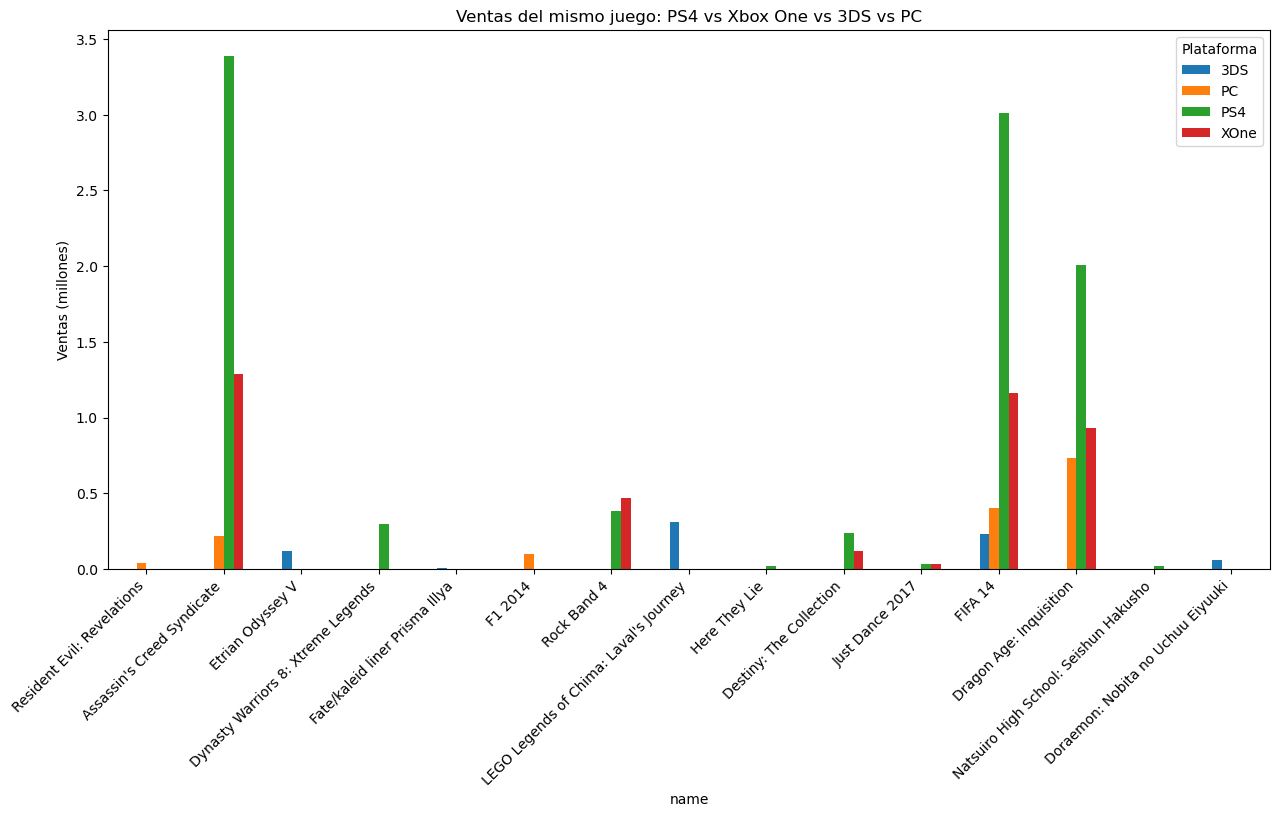

In [25]:
# 1. Filtramos y creamos la tabla dinámica
target_platforms = ['PS4', 'XOne', '3DS', 'PC']
multi_comp = df_recent[df_recent['platform'].isin(target_platforms)]

platform_comparison = multi_comp.pivot_table(index='name', 
                                             columns='platform', 
                                             values='total_sales', 
                                             aggfunc='sum')

# 2. En lugar de borrar (dropna), rellenamos los vacíos con 0
# Así no perdemos los juegos que solo salieron en PS4 y PC, por ejemplo.
platform_comparison_filled = platform_comparison.fillna(0)

# 3. Tomamos una muestra aleatoria de la tabla completa
comparison_sample = platform_comparison_filled.sample(15, random_state=42)

print("Muestra aleatoria incluyendo PC y 3DS (con valores 0 en lugar de NaN):")
print(comparison_sample)

# 4. Graficamos
comparison_sample.plot(kind='bar', figsize=(15, 7))
plt.title('Ventas del mismo juego: PS4 vs Xbox One vs 3DS vs PC')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Plataforma')
plt.show()

Conclusiones:

Al analizar la muestra aleatoria que incluye PS4, Xbox One, PC y 3DS, podemos observar dinámicas de mercado muy distintas:

PS4 como motor de ventas "Triple A": En juegos de gran presupuesto y alto impacto visual como Assassin's Creed Syndicate, FIFA 14 y Dragon Age: Inquisition, la PS4 domina ampliamente, superando por mucho (a veces el triple) a la Xbox One y al PC. Esto confirma que es la plataforma preferida por los consumidores para los grandes lanzamientos multiplataforma.

La Exclusividad de la 3DS: Observamos que juegos como Etrian Odyssey V, Fate/kaleid liner y Doraemon solo tienen ventas en 3DS (aparecen con 0 en el resto).

Conclusión: La 3DS sobrevive gracias a títulos de nicho japonés y franquicias infantiles que no necesitan potencia gráfica, sino portabilidad. No compite directamente con las consolas de sobremesa, sino que vive en su propio mercado.

El Rol del PC y la Xbox One:

El PC muestra ventas consistentes en títulos de rol y estrategia (como Dragon Age con 0.73M), pero queda rezagado en juegos de deportes o acción frente a las consolas.

La Xbox One se mantiene como una alternativa sólida a PS4, capturando una porción significativa del mercado de grandes títulos, aunque generalmente por debajo de la mitad del volumen de PlayStation.

Ceros y Nichos de Mercado:

Muchos juegos tienen "0" en varias columnas. Esto no es un error de datos, sino una prueba de que los desarrolladores eligen sus plataformas con cuidado: los juegos de nicho se quedan en 3DS y los grandes espectáculos visuales se quedan en PS4/XOne/PC.

3.8 Distribucion de ventas por genero

Estadísticas de Género (2013-2016):
                 sum      mean  count
genre                                
Action        322.22  0.420104    767
Shooter       232.98  1.245882    187
Sports        150.65  0.703972    214
Role-Playing  145.89  0.499623    292
Misc           62.82  0.405290    155
Platform       42.63  0.576081     74
Racing         39.89  0.469294     85
Fighting       35.31  0.441375     80
Adventure      23.64  0.096490    245
Simulation     21.76  0.350968     62
Strategy       10.08  0.180000     56
Puzzle          3.17  0.186471     17


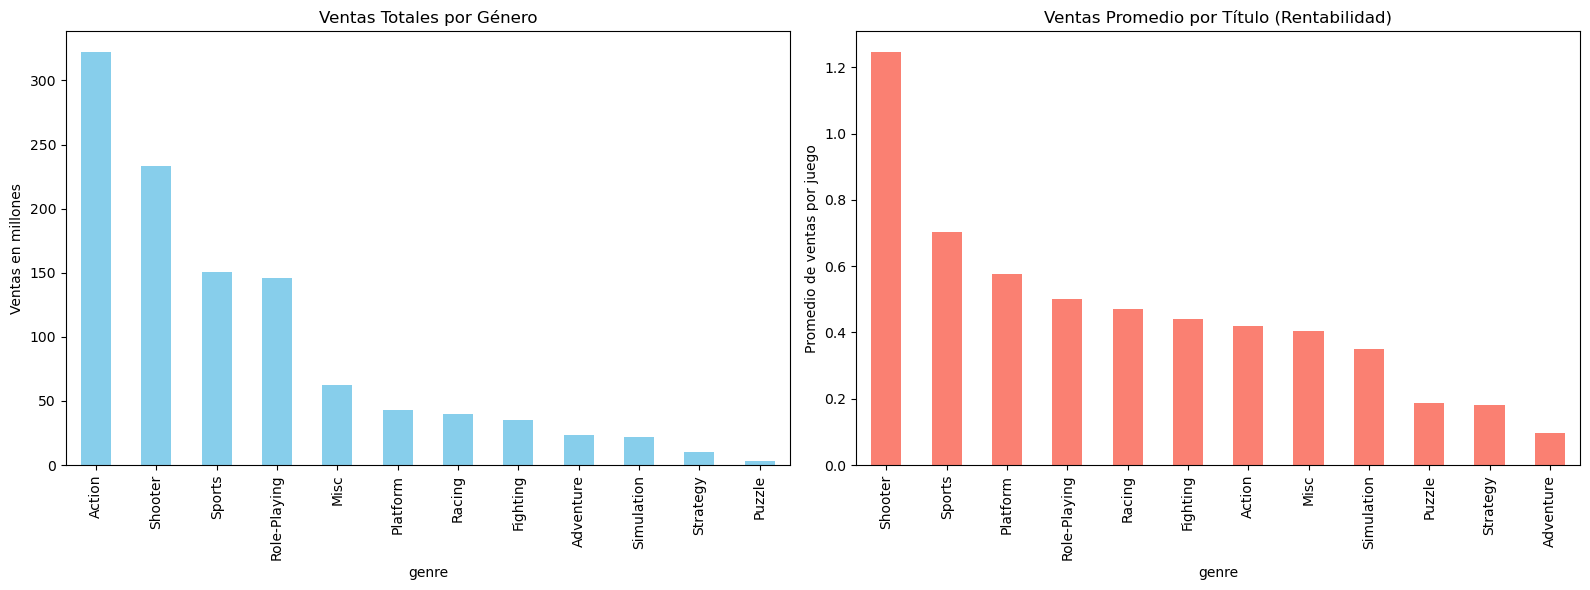

In [26]:
# 1. Agrupamos por género para calcular las estadísticas clave
# Usamos 'sum' para el volumen total y 'mean' para la rentabilidad promedio
genre_stats = df_recent.groupby('genre')['total_sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

print("Estadísticas de Género (2013-2016):")
print(genre_stats)

# 2. Visualizamos la comparativa con dos gráficos lado a lado
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Ventas Totales (Volumen)
genre_stats['sum'].plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Ventas Totales por Género')
ax[0].set_ylabel('Ventas en millones')

# Gráfico 2: Ventas Promedio (Rentabilidad Real por Juego)
# Ordenamos por 'mean' para ver quién es el más rentable
genre_stats['mean'].sort_values(ascending=False).plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Ventas Promedio por Título (Rentabilidad)')
ax[1].set_ylabel('Promedio de ventas por juego')

plt.tight_layout()
plt.show()

Tras comparar el volumen total de ventas frente a la rentabilidad promedio por título, se han obtenido las siguientes conclusiones clave:

Diferencia entre Popularidad y Rentabilidad: El género de Acción es el líder en ventas totales (322.22 millones) y cantidad de lanzamientos (767 títulos). Sin embargo, su promedio de ventas por juego es relativamente bajo (0.42). Esto sugiere un mercado saturado donde pocos títulos logran destacar masivamente.

Por el contrario, los Shooters presentan una rentabilidad superior. Aunque ocupan el segundo lugar en ventas totales (232.98 millones), tienen el promedio de ventas más alto por mucho ($1.24 por juego), casi triplicando al género de acción.

Géneros con Desempeño Sólido: Los géneros de Sports (0.70 de promedio) y Platform (0.57 de promedio) muestran una excelente relación entre cantidad de títulos y ventas. Son apuestas seguras con un público fiel que suele comprar los lanzamientos más importantes de manera consistente.

Géneros de Bajo Impacto Comercial: Géneros como Adventure, Strategy y Puzzle se encuentran en la parte baja de ambos indicadores. En particular, el género de aventura tiene muchos títulos (245) pero un promedio de ventas muy pobre (0.09), lo que indica que es un nicho con dificultades para generar éxitos comerciales masivos.

4. Crear un perfil de usuario para cada region

In [27]:
# Definimos las regiones
regions = ['na_sales', 'eu_sales', 'jp_sales']

# Creamos un diccionario para guardar los top 5 y facilitar la comparación
top_5_platforms = {}

for region in regions:
    # Calculamos ventas totales por plataforma en la región
    platform_sales = df_recent.groupby('platform')[region].sum().sort_values(ascending=False)
    
    # Calculamos el porcentaje (cuota de mercado)
    total_region_sales = platform_sales.sum()
    platform_share = (platform_sales / total_region_sales) * 100
    
    # Guardamos los 5 mejores
    top_5_platforms[region] = platform_share.head(5)
    
    print(f"Top 5 Plataformas en {region}:")
    print(top_5_platforms[region])
    print("-" * 30)

Top 5 Plataformas en na_sales:
platform
PS4     24.839528
XOne    21.271444
X360    18.653631
PS3     14.505334
3DS      8.726043
Name: na_sales, dtype: float64
------------------------------
Top 5 Plataformas en eu_sales:
platform
PS4     35.948329
PS3     17.277313
XOne    13.144619
X360    10.833673
3DS      7.888300
Name: eu_sales, dtype: float64
------------------------------
Top 5 Plataformas en jp_sales:
platform
3DS     48.167353
PS3     16.586163
PSV     13.205001
PS4     11.336838
WiiU     7.728371
Name: jp_sales, dtype: float64
------------------------------


Conclusiones: 

Al contrastar la distribución de ventas entre Norteamérica (NA), Europa (EU) y Japón (JP), se identifican divergencias estructurales en el consumo de hardware:Polarización vs. Equilibrio (NA vs. EU):Se observa una variación crítica en la competencia entre los dos líderes del mercado de sobremesa. Mientras que en Norteamérica la cuota de mercado está equilibrada entre PS4 (24.8%) y XOne (21.3%), en Europa existe una brecha de más de 22 puntos porcentuales a favor de Sony. Esto indica que la lealtad de marca hacia Xbox es un fenómeno predominantemente norteamericano, perdiendo tracción significativa en el territorio europeo.

Contraste Generacional:
Norteamérica presenta la mayor cuota de mercado para plataformas de la generación anterior (X360 con 18.6%), superando incluso a la PS3 en la misma región. En cambio, en Europa, la adopción de la nueva generación (PS4) ha sido mucho más agresiva, relegando a las consolas antiguas a porcentajes menores. Esta variación sugiere que el mercado norteamericano posee un ciclo de vida de producto más extendido para el ecosistema de Microsoft.

Divergencia de Formato (Occidente vs. Japón):La variación más drástica ocurre al comparar los mercados occidentales con el japonés. En NA y EU, las consolas portátiles (3DS) ocupan el último lugar del Top 5 con cuotas cercanas al 8%. Sin embargo, en Japón, la cuota de mercado de la 3DS (48.2) es casi seis veces mayor que en Occidente.

Exclusión de Marcas:Existe una variación total en la presencia de Microsoft. Mientras que en las regiones occidentales la marca Xbox ostenta entre el 13% y el 40% del mercado (sumando XOne y X360), en el mercado japonés su participación es nula en el Top 5, siendo desplazada por plataformas locales de menor rendimiento técnico pero mayor portabilidad como la PSV (13.2%) y la Wii U (7.7%).

4.1 Cinco generos principales

In [28]:
# Análisis de los Top 5 Géneros por Región
for region in regions:
    genre_sales = df_recent.groupby('genre')[region].sum().sort_values(ascending=False)
    total_region_sales = genre_sales.sum()
    genre_share = (genre_sales / total_region_sales) * 100
    
    print(f"Top 5 Géneros en {region.upper()}:")
    print(genre_share.head(5))
    print("-" * 30)

Top 5 Géneros en NA_SALES:
genre
Action          28.807365
Shooter         25.067958
Sports          14.909656
Role-Playing    10.599173
Misc             6.279553
Name: na_sales, dtype: float64
------------------------------
Top 5 Géneros en EU_SALES:
genre
Action          30.162046
Shooter         22.385854
Sports          15.419894
Role-Playing     9.419588
Racing           5.144211
Name: eu_sales, dtype: float64
------------------------------
Top 5 Géneros en JP_SALES:
genre
Role-Playing    36.255150
Action          28.761188
Misc             6.535019
Fighting         5.434011
Shooter          4.695269
Name: jp_sales, dtype: float64
------------------------------


Conclusiones:

El análisis de los cinco géneros principales por región permite identificar patrones de consumo que responden a factores culturales y de formato de plataforma:

Semejanza en el Eje Occidental (NA y EU):

Existe una correlación casi exacta entre los mercados de Norteamérica y Europa. En ambos, el género de Action lidera con un 28-30% de la cuota de mercado, seguido muy de cerca por los Shooters (~22-25%) y los Sports (~15%). Este perfil refleja una preferencia por títulos de alta fidelidad gráfica y dinámicas de juego rápidas, coherente con el dominio de las consolas de sobremesa (PS4/XOne) identificado en el punto anterior.


El Predominio del Role-Playing en Japón:

La variación más significativa ocurre en Japón, donde el género de Role-Playing es el líder indiscutible con un 36.25% de la cuota de mercado. A diferencia de Occidente, donde este género ocupa el cuarto lugar con apenas un 10%, en Japón supera a la Acción por casi 8 puntos porcentuales. Este dato está intrínsecamente ligado al éxito de la 3DS, plataforma principal para las franquicias de RPG más populares del país.

Divergencia en el Consumo de Shooters:

Se observa una variación drástica en la aceptación de los Shooters. Mientras que en Norteamérica es el segundo género más importante con un 25% de las ventas, en Japón cae al quinto lugar con apenas un 4.69%. Esto confirma que el género de disparos tiene una penetración de mercado cinco veces menor en el territorio nipón que en el estadounidense.Presencia de Géneros Secundarios (Misc y Fighting):Japón muestra una inclinación por géneros como Fighting (5.4%) y Misc (6.5%), desplazando a los juegos de Racing, los cuales solo logran entrar en el Top 5 de Europa. Esto refuerza la idea de un mercado japonés más orientado a experiencias de nicho, juegos sociales y mecánicas de combate tradicionales.



4.2 Clasificaciones de ESRB afectan a las ventanas en regiones individuales

In [29]:
# Ventas por Clasificación ESRB por Región
for region in regions:
    # Rellenamos los valores nulos con 'Unknown' para agruparlos
    esrb_stats = df_recent.fillna({'rating': 'Unknown'}).groupby('rating')[region].sum().sort_values(ascending=False)
    esrb_share = (esrb_stats / esrb_stats.sum()) * 100
    
    print(f"Cuota de Clasificación ESRB en {region.upper()}:")
    print(esrb_share)
    print("-" * 30)

Cuota de Clasificación ESRB en NA_SALES:
rating
M          37.752701
Unknown    20.426251
E          18.057427
E10+       12.390068
T          11.373552
Name: na_sales, dtype: float64
------------------------------
Cuota de Clasificación ESRB en EU_SALES:
rating
M          37.089788
E          21.239299
Unknown    20.105483
E10+       10.876987
T          10.688443
Name: eu_sales, dtype: float64
------------------------------
Cuota de Clasificación ESRB en JP_SALES:
rating
Unknown    60.413411
T          14.625657
E          10.754369
M          10.022731
E10+        4.183833
Name: jp_sales, dtype: float64
------------------------------


Conclusiones:

El análisis de las cuotas de mercado según la clasificación de la ESRB revela patrones de consumo diferenciados y pone de manifiesto las limitaciones territoriales de este sistema de clasificación:

Predominio del Contenido para Adultos en Occidente (NA y EU):
En las regiones de Norteamérica y Europa, la clasificación M (Mature) lidera con una cuota casi idéntica de aproximadamente el 37%. Esto confirma que una parte sustancial de los ingresos en estos mercados proviene de títulos dirigidos a un público adulto (vinculados al éxito de los géneros Action y Shooter). La clasificación E (Everyone) se mantiene como la segunda categoría identificable más fuerte, reflejando la relevancia de los juegos deportivos y familiares.

La Limitación Territorial de la ESRB en Japón:
El mercado japonés presenta una anomalía estadística fundamental: el 60.41% de las ventas corresponden a títulos con clasificación "Unknown".

Interpretación: Este elevado porcentaje no indica una falta de regulación, sino que confirma que la mayoría de los productos consumidos en Japón no pasan por el organismo estadounidense ESRB, utilizando en su lugar el sistema local CERO. Por lo tanto, para el mercado nipón, la clasificación ESRB no es un factor que afecte o prediga las ventas.

Divergencia en el Consumo Juvenil:
Se observa que en Japón, los juegos con clasificación T (Teen) tienen una presencia relativa mayor (14.6%) en comparación con Occidente (~11%). En contraste, los juegos E10+ tienen una penetración mínima en Japón (4.18%) frente a la relevancia que tienen en Norteamérica (12.39%). Esto sugiere que el contenido diseñado para pre-adolescentes tiene una estructura de mercado muy diferente entre estas regiones.

Relevancia de los Datos "Unknown" en Occidente:
Incluso en NA y EU, aproximadamente el 20% de las ventas corresponden a juegos sin clasificación ESRB. Esto sugiere la presencia de un mercado digital creciente, títulos independientes o juegos importados que logran un impacto comercial significativo sin adherirse a las clasificaciones tradicionales de las grandes editoras.

5. Probar hipotesis

In [30]:
# Filtrar datos para quitar valores ausentes en las calificaciones de usuarios
df_clean = df_recent.dropna(subset=['user_score'])

5.1 Xbox One vs. PC

Hipótesis: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Hipótesis Nula H_0: Las calificaciones promedio de los usuarios para Xbox One y PC son iguales.

Hipótesis Alternativa H_1: Las calificaciones promedio de los usuarios para Xbox One y PC son diferentes.

Valor Alfa (alpha): Establecemos 0.05$(5%). Es el estándar en la industria para equilibrar el riesgo de error.

In [31]:
xone_ratings = df_clean[df_clean['platform'] == 'XOne']['user_score']
pc_ratings = df_clean[df_clean['platform'] == 'PC']['user_score']

results = st.ttest_ind(xone_ratings, pc_ratings, equal_var=False) # Suponemos varianzas diferentes

print('p-value:', results.pvalue)

if results.pvalue < 0.05:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

p-value: 0.17156613829336056
No podemos rechazar la hipótesis nula


Esto significa que los usuarios califican de manera similar ambas plataformas, por lo que la calidad percibida no es un factor diferenciador entre estas plataformas"

5.2 Acción vs. Deportes

Hipótesis: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes

Hipótesis Nula (H_0): Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

Hipótesis Alternativa (H_1) Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Valor Alfa (alpha): 0.05.

In [32]:
action_ratings = df_clean[df_clean['genre'] == 'Action']['user_score']
sports_ratings = df_clean[df_clean['genre'] == 'Sports']['user_score']

results = st.ttest_ind(action_ratings, sports_ratings, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < 0.05:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

p-value: 1.1834440653354691e-20
Rechazamos la hipótesis nula


Esto confirma que existe una diferencia significativa en cómo los usuarios califican estos géneros. 

Análisis de Hipótesis Estadísticas:

Para validar las tendencias observadas, se realizaron dos pruebas de significancia estadística utilizando los resultados obtenidos:

1. Formulación de las Hipótesis
La configuración de las hipótesis se basó en el principio de falsabilidad estadística:

Hipótesis Nula (H_0): Se establece siempre como un estado de igualdad. Planteamos que no existe una diferencia real entre las medias de los grupos y que cualquier variación observada es producto del azar.

Hipótesis Alternativa (H_1): Se establece como la negación de la nula. Planteamos que existe una diferencia estadísticamente significativa entre los grupos analizados.

2. Criterio y Metodología de Prueba
Para ambas pruebas, se seleccionó el siguiente criterio técnico:

Prueba t de Student para muestras independientes: Se eligió este método porque estamos comparando las medias de dos poblaciones distintas (Xbox vs. PC y Acción vs. Deportes) que no dependen la una de la cual.

Ajuste de Welch (equal_var=False): Se utilizó este parámetro debido a que las muestras no tienen el mismo tamaño ni necesariamente la misma varianza. Esto hace que la prueba sea más robusta y precisa.

Umbral de significancia (alpha): Se estableció en 0.05 (5%). Este nivel es el estándar en análisis de datos, permitiéndonos tener un 95% de confianza en que los resultados no son casualidad.

Los resultados confirman que mientras las plataformas Xbox One y PC ofrecen experiencias de calidad similar según los usuarios, existe una diferencia significativa en la percepción de calidad entre géneros Action y Sports, lo que debe considerarse en las estrategias de marketing por género.

6. Conclusion general

Tras realizar un análisis exhaustivo de los datos históricos y las tendencias recientes (2013-2016) de la industria de los videojuegos, se presentan las siguientes conclusiones clave:

1. Ciclo de Vida y Plataformas Clave
El mercado se encuentra en una fase de consolidación de la "octava generación". Las plataformas con mayor potencial de crecimiento y rentabilidad para 2017 son PS4 y Xbox One, las cuales han demostrado ser líderes en ventas y adopción tecnológica. En el mercado portátil, la 3DS mantiene una relevancia crítica, especialmente en el sector asiático.

2. Segmentación Regional y Perfil del Consumidor
Se identificaron tres perfiles de usuario claramente diferenciados que requieren estrategias de inventario específicas:

Norteamérica (NA): Un mercado competitivo donde Xbox One y PS4 disputan el liderazgo. Existe una fuerte preferencia por los géneros de Acción y Shooters, con una alta sensibilidad a las clasificaciones M (Mature) de la ESRB.

Europa (EU): Una región dominada ampliamente por PlayStation. Al igual que en NA, el contenido de Acción y los títulos con clasificación para adultos son los motores de venta, aunque con una mayor apertura a géneros deportivos.

Japón (JP): Un ecosistema único centrado en la portabilidad (3DS) y el género Role-Playing. Es imperativo notar que el sistema de clasificación ESRB no influye en las decisiones de compra, ya que el mercado se rige por estándares locales y preferencias culturales distintas a las occidentales.

3. Factores de Éxito y Calificaciones
Mediante las pruebas estadísticas, se determinó que:

Las plataformas no definen la satisfacción: No existe diferencia significativa entre las calificaciones de usuarios de Xbox One y PC, lo que sugiere que la calidad del software es independiente del hardware en estos sistemas.

Divergencia por Género: Existe una diferencia estadística contundente en las calificaciones de los géneros de Acción y Deportes, indicando que los usuarios son más críticos o tienen expectativas distintas según la mecánica del juego.

Influencia Crítica: Se observó que las calificaciones de la crítica profesional tienen una correlación más fuerte con las ventas que las calificaciones de los usuarios, funcionando como un predictor de éxito comercial más fiable.

4. Recomendación Estratégica
Para maximizar las ganancias en 2017, la tienda debe:

Priorizar títulos AAA de los géneros Shooter y Action para PS4 y Xbox One en el mercado occidental.

Asegurar stock de RPGs y títulos de Nintendo para la 3DS enfocados al mercado japonés.

Monitorear las puntuaciones de la crítica antes de los lanzamientos para ajustar las campañas de marketing, dado su impacto directo en el volumen de ventas.